# 🧩 Notebook 02 — Data Loading and Preprocessing

*Author: Dr. Taiwo A. Famuyiwa*  
*Date: October 2025*

This notebook handles handles data importation, cleaning, transformation, and preprocessing for the Heart Disease Prediction project.
We'll use the UCI Heart Disease dataset as our source.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

Mounted at /content/drive


## Setup Imports

In [ ]:
#Basic packages
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




#Set display options
pd.set_option("display.max_columns", None)



#Ensure we can import from src/
os.chdir('/content/drive/MyDrive/Dr. Taiwo famuyiwa - Data Science & Biostatistics Portfolio/Machine Learning Projects/Heart-Disease-Prediction')
sys.path.append(os.getcwd())

from src.data import load_data, split_save

## Load Dataset from UCI (via src/data.py)

In [ ]:
# Load the UCI dataset (auto-downloads if missing)
df = load_data()




print("✅ Dataset Loaded Successfully!")
print(f"Shape: {df.shape}")
df.head()

⚠️ Detected headerless dataset — applying fix.
✅ Fixed headerless dataset saved to: data/raw/data.csv
✅ Dataset loaded and verified successfully!
✅ Dataset Loaded Successfully!
Shape: (304, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,53.0,1.0,3.0,130.0,246.0,1.0,2.0,173.0,0.0,0.0,1.0,3.0,3.0,0
1,55.0,1.0,4.0,160.0,289.0,0.0,2.0,145.0,1.0,0.8,2.0,1.0,7.0,1
2,61.0,0.0,4.0,145.0,307.0,0.0,2.0,146.0,1.0,1.0,2.0,0.0,7.0,1
3,58.0,1.0,4.0,100.0,234.0,0.0,0.0,156.0,0.0,0.1,1.0,1.0,7.0,1
4,51.0,1.0,1.0,125.0,213.0,0.0,2.0,125.0,1.0,1.4,1.0,1.0,3.0,0


## Inspect Dataset Information



In [ ]:
# Basic info
df.info()


#Summary statistics
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       304 non-null    float64
 1   sex       304 non-null    float64
 2   cp        304 non-null    float64
 3   trestbps  304 non-null    float64
 4   chol      304 non-null    float64
 5   fbs       304 non-null    float64
 6   restecg   304 non-null    float64
 7   thalach   304 non-null    float64
 8   exang     304 non-null    float64
 9   oldpeak   304 non-null    float64
 10  slope     304 non-null    float64
 11  ca        304 non-null    object 
 12  thal      304 non-null    object 
 13  target    304 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.4+ KB


,count,mean,std,min,25%,50%,75%,max
age,304.0,54.259868,9.548637,0.0,47.75,55.5,61.0,77.0
sex,304.0,0.680921,0.466888,0.0,0.00,1.0,1.0,1.0
cp,304.0,3.154605,0.960840,1.0,3.00,3.0,4.0,4.0
trestbps,304.0,131.266447,19.057964,3.0,120.00,130.0,140.0,200.0
chol,304.0,245.894737,53.532712,4.0,211.00,240.5,275.0,564.0
fbs,304.0,0.164474,0.451533,0.0,0.00,0.0,0.0,5.0
restecg,304.0,1.006579,1.034052,0.0,0.00,1.0,2.0,6.0
thalach,304.0,149.138158,24.257706,7.0,133.00,152.5,166.0,202.0
exang,304.0,0.351974,0.643164,0.0,0.00,0.0,1.0,8.0
oldpeak,304.0,1.065789,1.245830,0.0,0.00,0.8,1.6,9.0


## Checking for Missing Values

In [ ]:
# Check for missing data
missing = df.isnull().sum()
missing[missing > 0]

,0


## Handle Missing or Invalid Entries


In [ ]:
# Simple example of handling missing values
df = df.dropna()  # or use imputation if needed
print(f"✅ After cleaning, shape: {df.shape}")

✅ After cleaning, shape: (304, 14)


## Check for Duplicates


In [ ]:
duplicates = df.duplicated().sum()
print(f"🔁 Duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("✅ Duplicates removed.")

🔁 Duplicate rows: 0


## Quick Exploratory

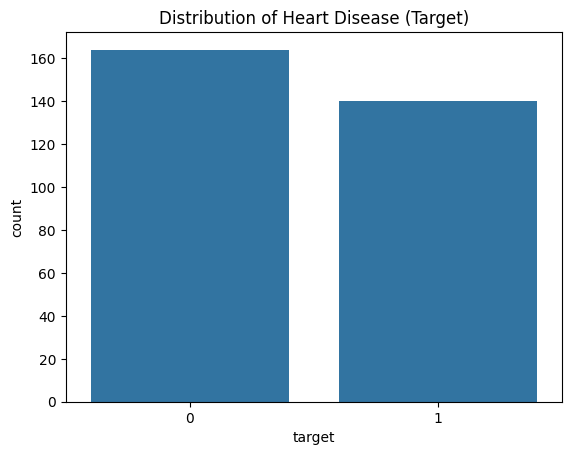

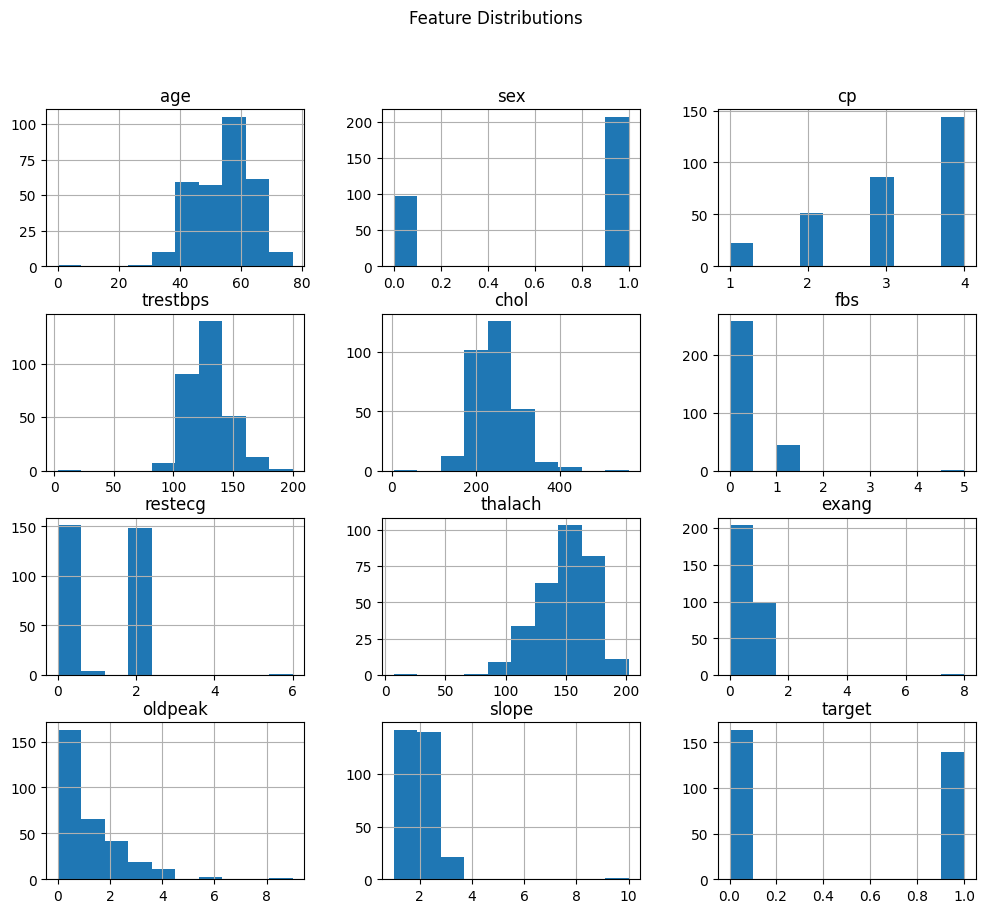

In [ ]:
# Target balance
sns.countplot(x="target", data=df)
plt.title("Distribution of Heart Disease (Target)")
plt.show()

# Numeric summary
df.hist(figsize=(12, 10))
plt.suptitle("Feature Distributions")
plt.show()

## Outlier & Value Range Checks

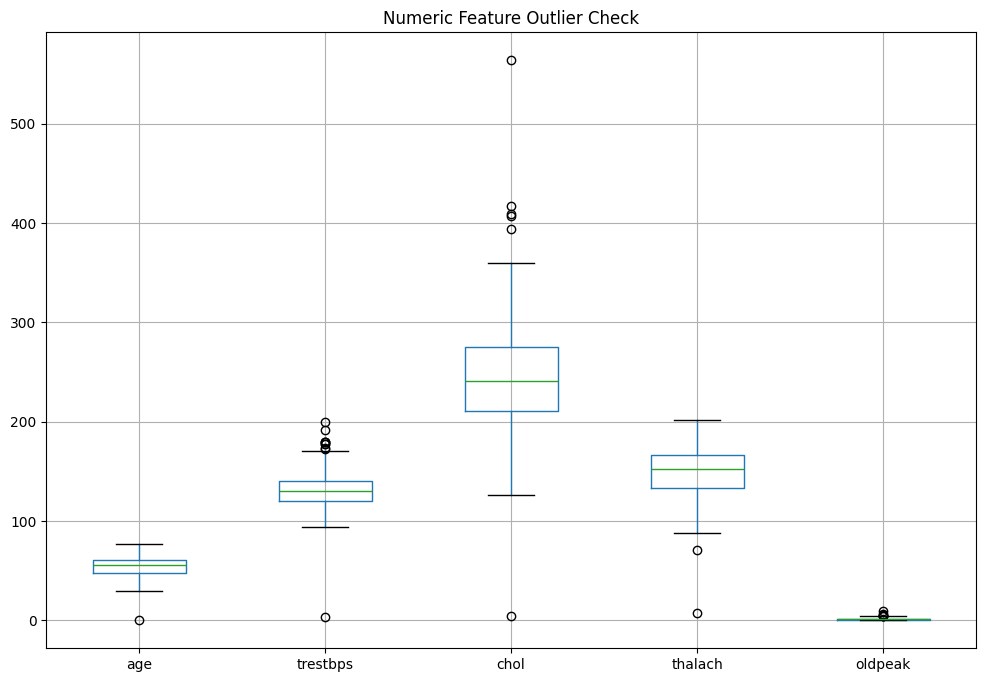

In [ ]:
# Boxplots to inspect outliers
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
plt.figure(figsize=(12, 8))
df[num_cols].boxplot()
plt.title("Numeric Feature Outlier Check")
plt.show()

## Correlation Heatmap

Missing values after converting 'ca' and 'thal':
ca      4
thal    2
dtype: int64

Filled missing values in 'ca' with mode: 0.0

Filled missing values in 'thal' with mode: 3.0


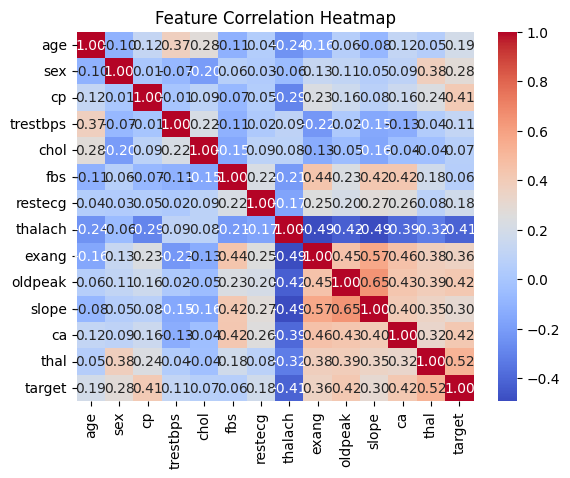

In [ ]:
# Convert 'ca' and 'thal' to numeric, replacing '?' with NaN
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')

# Check for missing values after conversion
print("Missing values after converting 'ca' and 'thal':")
print(df.isnull().sum()[['ca', 'thal']])

# Since the isnull().sum() in cell gkekjT9Jbctb showed no missing values before,
# these NaNs introduced by 'coerce' are the '?' values.
# We can choose to fill these NaNs with a value (like the mode or median)
# or drop the rows. For now, let's see how many there are.
# A common approach for categorical/ordinal data like 'ca' and 'thal'
# is to impute with the mode.

# Impute with the mode
for col in ['ca', 'thal']:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"\nFilled missing values in '{col}' with mode: {mode_val}")


# Now, generate the heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#Save clean version before splittiing
os.makedirs("data/raw", exist_ok=True)
df.to_csv("data/raw/data.csv", index = False)



#Split into train/val/test using src/data.py
split_save(df)

✅ Saved splits in data/processed/


In [ ]:
## Verify Processed Files
import glob
print(glob.glob("data/processed/*.csv"))

['data/processed/X_train.csv', 'data/processed/X_val.csv', 'data/processed/X_test.csv', 'data/processed/y_train.csv', 'data/processed/y_val.csv', 'data/processed/y_test.csv']


## Notebook Summary

### ✅ Summary
- Loaded and explored UCI Heart Disease dataset  
- Cleaned missing values and duplicates  
- Checked data balance, outliers, and correlations  
- Saved clean data → `data/raw/heart.csv`  
- Created processed splits (train, val, test) → `data/processed/`


Next Notebook → **03_EDA.ipynb**